In [22]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [4]:
# --- CONFIGURATION ---
YEARS = list(range(2000, 2023))
CSV_DIR = './spatial_clusters_fixed'  # Folder containing CSVs
FILE_PATTERN = 'spatial_{year}.csv'
ID_COL = 's2_id'
CLUSTER_COL = 'cluster'
STABILITY_THRESHOLD = 70.0 # Percentage to consider a grid 'stable'
CLUSTER_COL = 'cluster'
FRAC_COLS = [
    'crop_frac', 'tree_frac', 'shrub_frac', 'bare_frac', 
    'water_frac', 'built_frac', 'wetland_frac', 'snow_frac'
]
# Mapping column names to cleaner labels
CLASS_LABELS = {c: c.replace('_frac', '').capitalize() for c in FRAC_COLS}

In [10]:
def load_and_process_spatial_data():
    """
    Loads spatial cluster files and aggregates cluster assignments and class fractions.
    """
    cluster_series = {} # To store {s2_id: [cluster_yr1, cluster_yr2, ...]}
    frac_sums = {}      # To store {s2_id: np.array([sum_crop, sum_tree, ...])}
    counts = {}         # To track number of years each grid appears

    for year in YEARS:
        path = os.path.join(CSV_DIR, FILE_PATTERN.format(year=year))
        if not os.path.exists(path):
            print(f"[MISSING] {path}")
            continue
        
        print(f"Processing year {year}...")
        df = pd.read_csv(path, dtype={ID_COL: str})
        
        for _, row in df.iterrows():
            sid = row[ID_COL]
            cluster = row[CLUSTER_COL]
            fracs = row[FRAC_COLS].values.astype(float)
            
            # Update Cluster tracking
            if sid not in cluster_series:
                cluster_series[sid] = []
                frac_sums[sid] = np.zeros(len(FRAC_COLS))
                counts[sid] = 0
            
            cluster_series[sid].append(cluster)
            frac_sums[sid] += fracs
            counts[sid] += 1

    # Convert to Dataframe for Stability Analysis
    results = []
    print("Calculating metrics per grid cell...")
    for sid in cluster_series:
        # 1. Stability Metrics
        c_list = cluster_series[sid]
        mode_val, mode_count = Counter(c_list).most_common(1)[0]
        stability = (mode_count / len(c_list)) * 100
        
        # 2. Determine Dominant Class (highest average fraction)
        avg_fracs = frac_sums[sid] / counts[sid]
        dom_class_idx = np.argmax(avg_fracs)
        dom_class_name = FRAC_COLS[dom_class_idx]
        
        results.append({
            ID_COL: sid,
            'stability': stability,
            'dominant_class': dom_class_name,
            'valid_years': counts[sid]
        })
        
    return pd.DataFrame(results)

def plot_classwise_stability(df):
    """
    Creates a grid of stability histograms for each of the 8 classes.
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=False)
    axes = axes.flatten()
    
    for i, class_col in enumerate(FRAC_COLS):
        class_df = df[df['dominant_class'] == class_col]
        label = CLASS_LABELS[class_col]
        
        ax = axes[i]
        if not class_df.empty:
            ax.hist(class_df['stability'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
            ax.axvline(70, color='red', linestyle='--', alpha=0.6)
            ax.set_title(f"{label} (n={len(class_df)})")
            # Stats for annotation
            mean_stab = class_df['stability'].mean()
            ax.text(0.05, 0.9, f"Mean: {mean_stab:.1f}%", transform=ax.transAxes, fontweight='bold')
        else:
            ax.set_title(f"{label} (No Data)")
            
        if i >= 4: ax.set_xlabel("Stability (%)")
        if i % 4 == 0: ax.set_ylabel("Number of Grids")

    plt.suptitle("Cluster Stability Distribution by Dominant Land Cover Class", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('classwise_stability_histograms.png', dpi=150)
    plt.show()

def plot_combined_kde(df):
    """
    Comparison KDE plot for all classes (similar to your phenology notebook).
    """
    plt.figure(figsize=(12, 7))
    
    for class_col in FRAC_COLS:
        class_data = df[df['dominant_class'] == class_col]['stability']
        if len(class_data) > 1: # KDE requires at least 2 points
            class_data.plot(kind='kde', label=CLASS_LABELS[class_col])
            
    plt.title("Stability Comparison Across 8 Major Classes", fontsize=15)
    plt.xlabel("Stability (% frequency of modal cluster)")
    plt.ylabel("Density")
    plt.xlim(0, 100)
    plt.legend(title="Dominant Class")
    plt.grid(axis='both', alpha=0.3)
    plt.savefig('class_stability_comparison_kde.png', dpi=150)
    plt.show()

In [12]:
master_df = load_and_process_spatial_data()

Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Calculating metrics per grid cell...


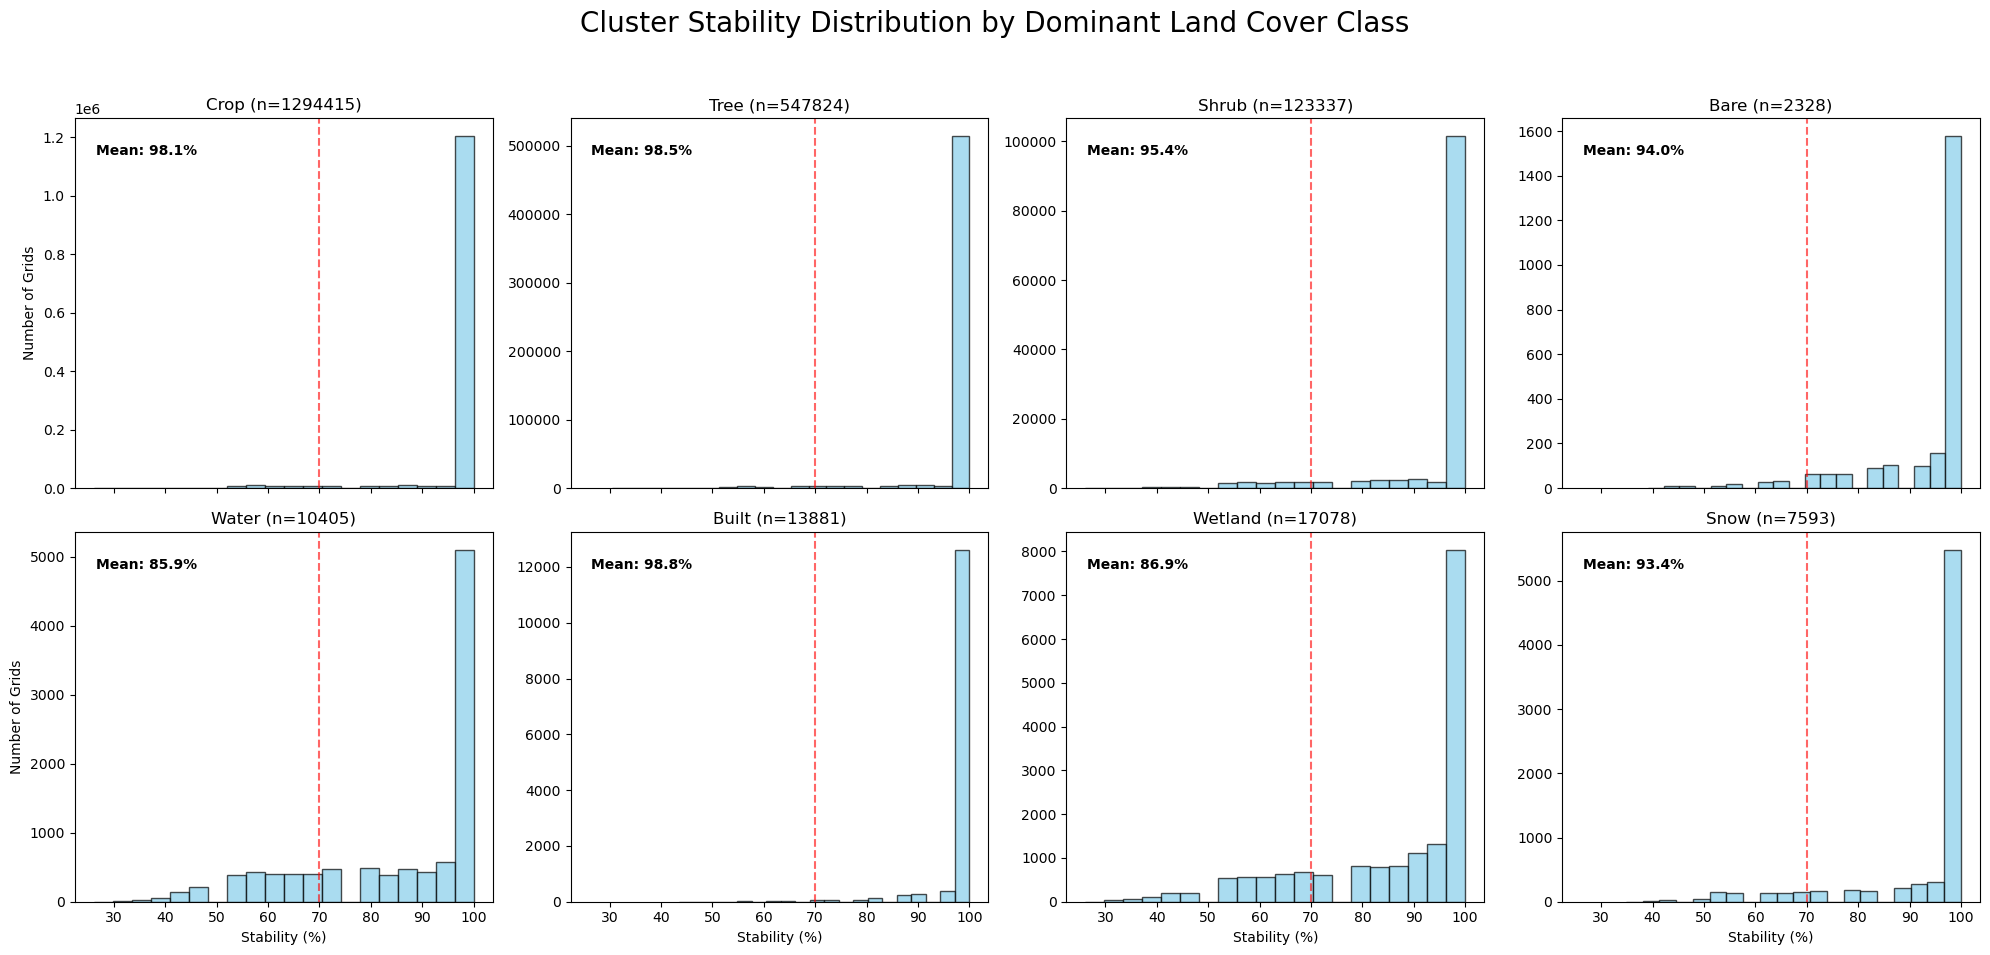

In [13]:
plot_classwise_stability(master_df)

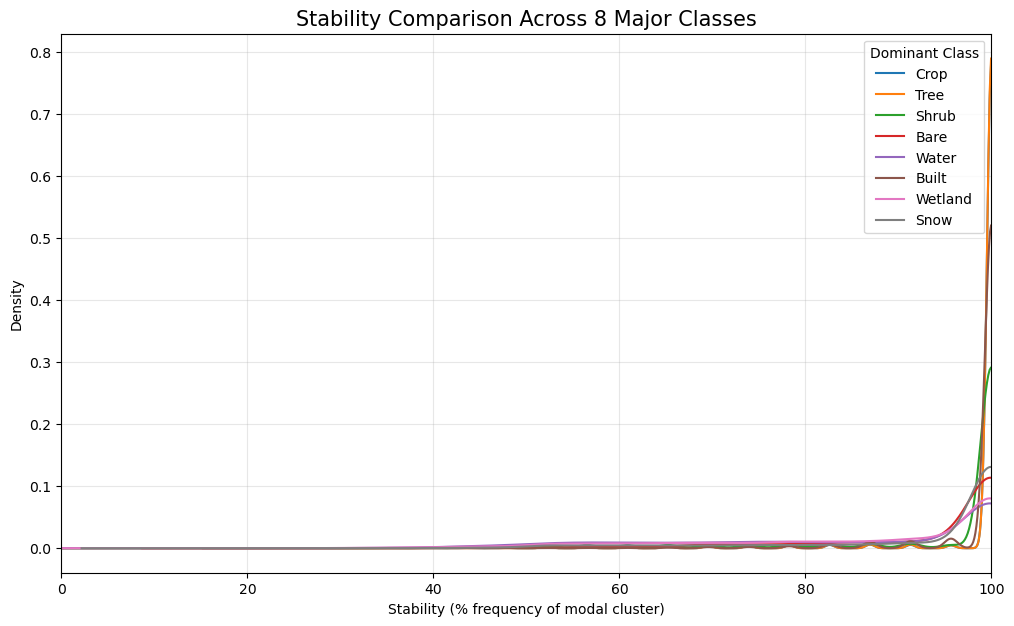

In [14]:
plot_combined_kde(master_df)

In [5]:
def load_spatial_data():
    """
    Loads CSV files for each year and merges them into a single wide DataFrame.
    Rows: s2_id, Columns: Years, Values: Cluster ID
    """
    dfs = []
    for year in YEARS:
        # Construct the file path
        path = os.path.join(CSV_DIR, FILE_PATTERN.format(year=year))
        
        if not os.path.exists(path):
            print(f"[MISSING] {path}")
            continue
            
        print(f"Loading {year}...")
        # Read the CSV, ensuring IDs are strings to avoid precision issues
        df = pd.read_csv(path, dtype={ID_COL: str})
        
        # Keep only the ID and the cluster assignment
        df = df[[ID_COL, CLUSTER_COL]]
        
        # Ensure cluster is an integer, use -1 for missing values
        df[CLUSTER_COL] = pd.to_numeric(df[CLUSTER_COL], errors='coerce').fillna(-1).astype(int)
        
        # Rename column to the year for the wide format
        df = df.rename(columns={CLUSTER_COL: str(year)})
        dfs.append(df.set_index(ID_COL))
    
    # Merge all years into one large dataframe
    full_df = pd.concat(dfs, axis=1)
    return full_df

def compute_stability_metrics(df):
    """
    Computes stability metrics for each spatial ID.
    """
    results = []
    print("Computing stability metrics...")
    
    for s2_id, row in df.iterrows():
        # Filter out missing data (-1)
        valid = row[row != -1]
        
        if len(valid) == 0:
            results.append({
                ID_COL: s2_id,
                'mode_cluster': -1,
                'mode_freq': 0,
                'stability_pct': 0.0,
                'n_unique': 0,
                'is_stable': False,
                'valid_years': 0
            })
            continue
            
        counts = Counter(valid)
        mode_cls, mode_freq = counts.most_common(1)[0]
        stab_pct = round(mode_freq / len(valid) * 100, 1)
        
        results.append({
            ID_COL: s2_id,
            'mode_cluster': mode_cls,
            'mode_freq': mode_freq,
            'stability_pct': stab_pct,
            'n_unique': len(counts),
            'is_stable': stab_pct >= STABILITY_THRESHOLD,
            'valid_years': len(valid)
        })
        
    return pd.DataFrame(results).set_index(ID_COL)

def plot_stability_results(stability_df):
    """
    Generates a histogram of stability percentages.
    """
    plt.figure(figsize=(10, 6))
    s = stability_df['stability_pct']
    plt.hist(s[s > 0], bins=20, color='teal', edgecolor='white')
    plt.axvline(STABILITY_THRESHOLD, color='red', linestyle='--', 
                label=f'{STABILITY_THRESHOLD}% threshold')
    
    plt.title('Spatial Cluster Stability Distribution (2000-2022)')
    plt.xlabel('% years assigned to the most frequent (modal) cluster')
    plt.ylabel('Number of grids')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('spatial_stability_histogram.png', dpi=150)
    plt.show()

def plot_transitions(wide_df):
    """
    Calculates and plots the percentage of grids that change cluster year-over-year.
    """
    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    change_rates = []
    
    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i+1]
        # Only compare grids present in both years and not -1
        both = wide_df[[y1, y2]].replace(-1, np.nan).dropna()
        if len(both) == 0: continue
        
        changed = (both[y1] != both[y2]).sum()
        total = len(both)
        change_rates.append({
            'transition': f'{y1}→{y2}',
            'pct_changed': round(changed / total * 100, 1)
        })
    
    tr_df = pd.DataFrame(change_rates)
    
    plt.figure(figsize=(15, 5))
    plt.bar(tr_df['transition'], tr_df['pct_changed'], color='salmon', edgecolor='white')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.ylabel('% grids that changed cluster')
    plt.title('Year-over-Year Spatial Cluster Transitions')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('spatial_transitions.png', dpi=150)
    plt.show()

In [6]:
# 1. Load data
wide_data = load_spatial_data()

Loading 2000...
Loading 2001...
Loading 2002...
Loading 2003...
Loading 2004...
Loading 2005...
Loading 2006...
Loading 2007...
Loading 2008...
Loading 2009...
Loading 2010...
Loading 2011...
Loading 2012...
Loading 2013...
Loading 2014...
Loading 2015...
Loading 2016...
Loading 2017...
Loading 2018...
Loading 2019...
Loading 2020...
Loading 2021...
Loading 2022...


In [5]:
# 2. Run analysis
stability_results = compute_stability_metrics(wide_data)

Computing stability metrics...


In [6]:
# 3. Print Summary
print(f"Stable grids (>= {STABILITY_THRESHOLD}%): {stability_results['is_stable'].sum()} / {len(stability_results)}")
print(f"Average Stability: {stability_results['stability_pct'].mean():.2f}%")

Stable grids (>= 70.0%): 1944532 / 2016861
Average Stability: 97.88%


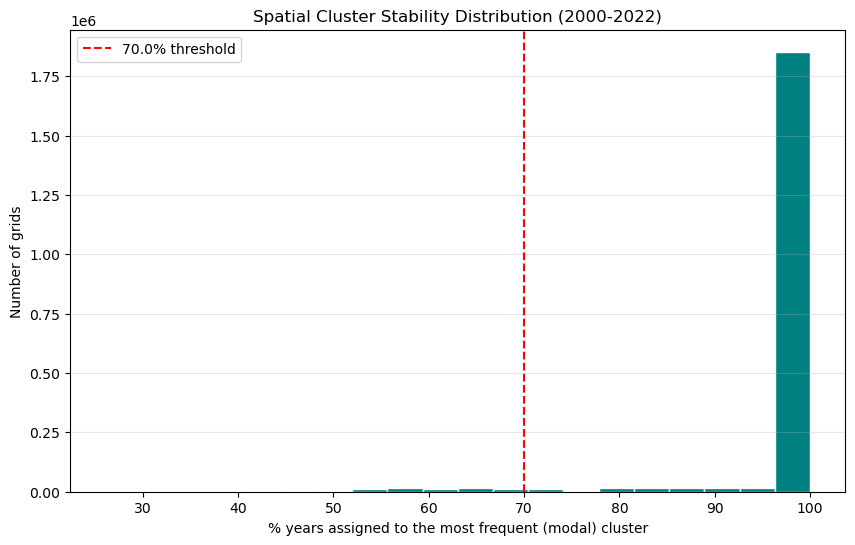

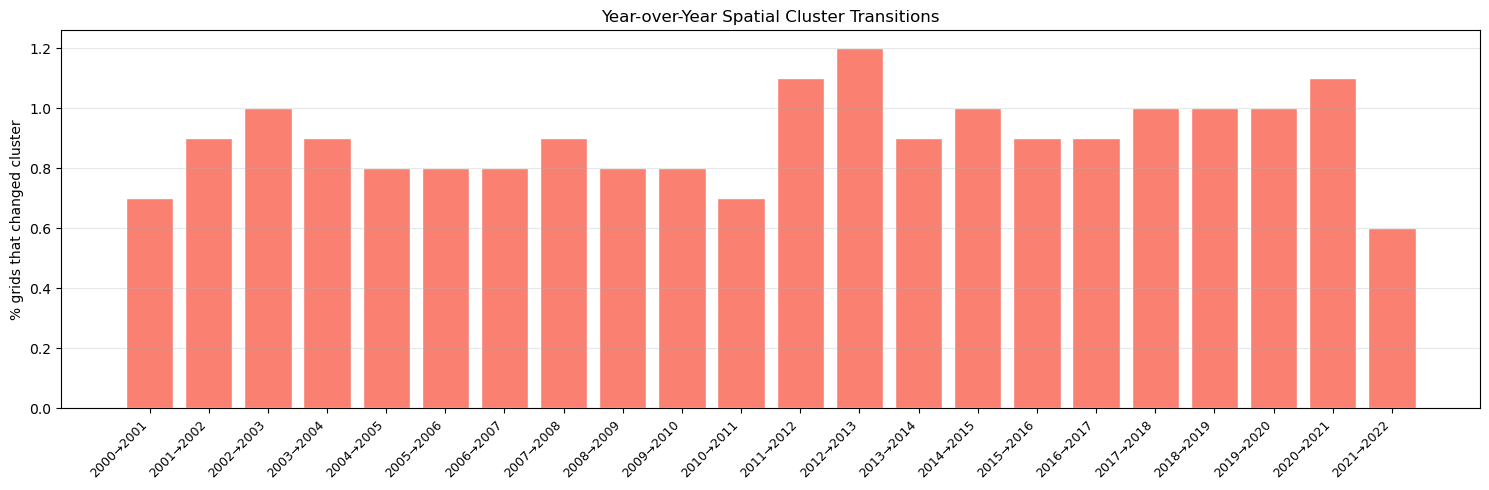

In [7]:
# 4. Visualize
plot_stability_results(stability_results)
plot_transitions(wide_data)

In [15]:
def plot_transitions_per_cluster(wide_df, n_clusters=8):
    """
    Calculates and plots the number of grids that changed cluster year-over-year,
    broken down by their original cluster.
    """
    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    
    # We will store counts in a dictionary: {transition_name: [counts_for_cluster_0, ... cluster_7]}
    transition_data = {}
    labels = []

    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i+1]
        label = f'{y1}→{y2}'
        labels.append(label)
        
        # Only compare grids present in both years and not -1
        both = wide_df[[y1, y2]].replace(-1, np.nan).dropna()
        
        cluster_changes = []
        for c in range(n_clusters):
            # 1. Look at grids that were in cluster 'c' in the first year
            starts_in_c = both[both[y1] == c]
            
            # 2. Count how many of those are NOT in cluster 'c' in the second year
            if len(starts_in_c) > 0:
                num_changed = (starts_in_c[y1] != starts_in_c[y2]).sum()
            else:
                num_changed = 0
            
            cluster_changes.append(num_changed)
        
        transition_data[label] = cluster_changes

    # Convert to DataFrame for easier plotting
    # Rows: Transitions, Columns: Clusters 0-7
    plot_df = pd.DataFrame(transition_data, index=[f'Cluster {i}' for i in range(n_clusters)]).T

    # Plotting
    plt.figure(figsize=(15, 7))
    
    # We use a stacked bar to show the contribution of each cluster to the total change
    plot_df.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='tab10', edgecolor='white')
    
    plt.title('Year-over-Year Cluster Transitions (Broken down by Source Cluster)')
    plt.xlabel('Year Transition')
    plt.ylabel('Number of Grids that Changed')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Original Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('spatial_transitions_per_cluster.png', dpi=150)
    plt.show()


<Figure size 1500x700 with 0 Axes>

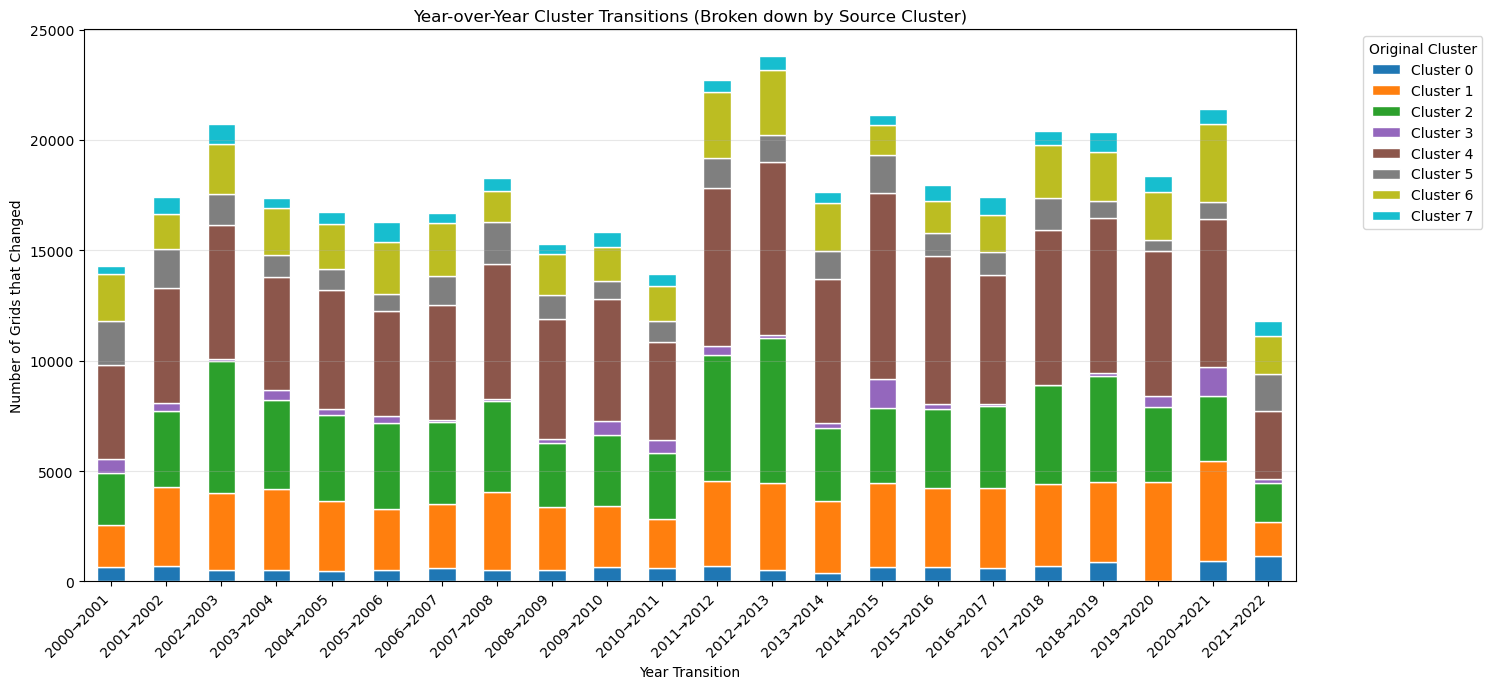

In [16]:
plot_transitions_per_cluster(wide_data, n_clusters=8)

In [9]:
def plot_transitions_per_cluster_percentage(wide_df, n_clusters=8):
    """
    Plots the percentage of grids that changed out of each cluster in separate subplots
    using descriptive cluster names instead of numerical IDs.
    """
    # Mapping dictionary based on your cluster descriptions
    cluster_names = {
        0: "Agricultural-residential areas",
        1: "Mostly trees",
        2: "Mostly shrublands",
        3: "Himalayan areas",
        4: "Intensive croplands",
        5: "Riverine and coastal areas",
        6: "Mostly wetlands",
        7: "Mostly bare areas"
    }

    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    transition_data = {}
    labels = []

    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i+1]
        label = f'{y1}→{y2}'
        labels.append(label)
        
        both = wide_df[[y1, y2]].replace(-1, np.nan).dropna()
        cluster_percentages = []
        
        for c in range(n_clusters):
            # Grids that started in cluster c during year y1
            starts_in_c = both[both[y1] == c]
            total_in_cluster = len(starts_in_c)
            
            if total_in_cluster > 0:
                # Number of grids that changed to a different cluster in y2
                num_changed = (starts_in_c[y1] != starts_in_c[y2]).sum()
                # Calculate percentage
                pct_changed = (num_changed / total_in_cluster) * 100
            else:
                pct_changed = 0.0
                
            cluster_percentages.append(pct_changed)
        
        transition_data[label] = cluster_percentages

    # Use descriptive column identifiers for the data frame to keep tracks clean
    plot_df = pd.DataFrame(transition_data, index=[f'Cluster {i}' for i in range(n_clusters)]).T

    # Setup subplots: 4 rows, 2 columns for 8 clusters
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20), sharex=True)
    axes = axes.flatten()
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    for i in range(n_clusters):
        cluster_id_label = f'Cluster {i}'
        # Fallback to generic name if index out of dictionary range
        descriptive_name = cluster_names.get(i, f"Cluster {i}") 
        ax = axes[i]
        
        ax.bar(plot_df.index, plot_df[cluster_id_label], color=colors[i], edgecolor='black', alpha=0.8)
        
        # Updated to display the descriptive name in the subplot titles
        ax.set_title(f'Transitions Out of {descriptive_name} (%)', fontsize=13, fontweight='bold')
        ax.set_ylabel('% of Grids Changed')
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        
        # Ensure the y-axis represents percentages neatly up to 100% if needed
        ax.set_ylim(0, max(plot_df[cluster_id_label].max() * 1.1, 10)) 
        
        # Rotate x-labels only for the bottom plots
        if i >= 6:
            ax.set_xticklabels(plot_df.index, rotation=45, ha='right')

    plt.suptitle('Yearly Transition Percentage per Source Cluster (Stability Metric)', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

C:\Users\navan\AppData\Local\Temp\ipykernel_27520\3450990034.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df.index, rotation=45, ha='right')
C:\Users\navan\AppData\Local\Temp\ipykernel_27520\3450990034.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df.index, rotation=45, ha='right')


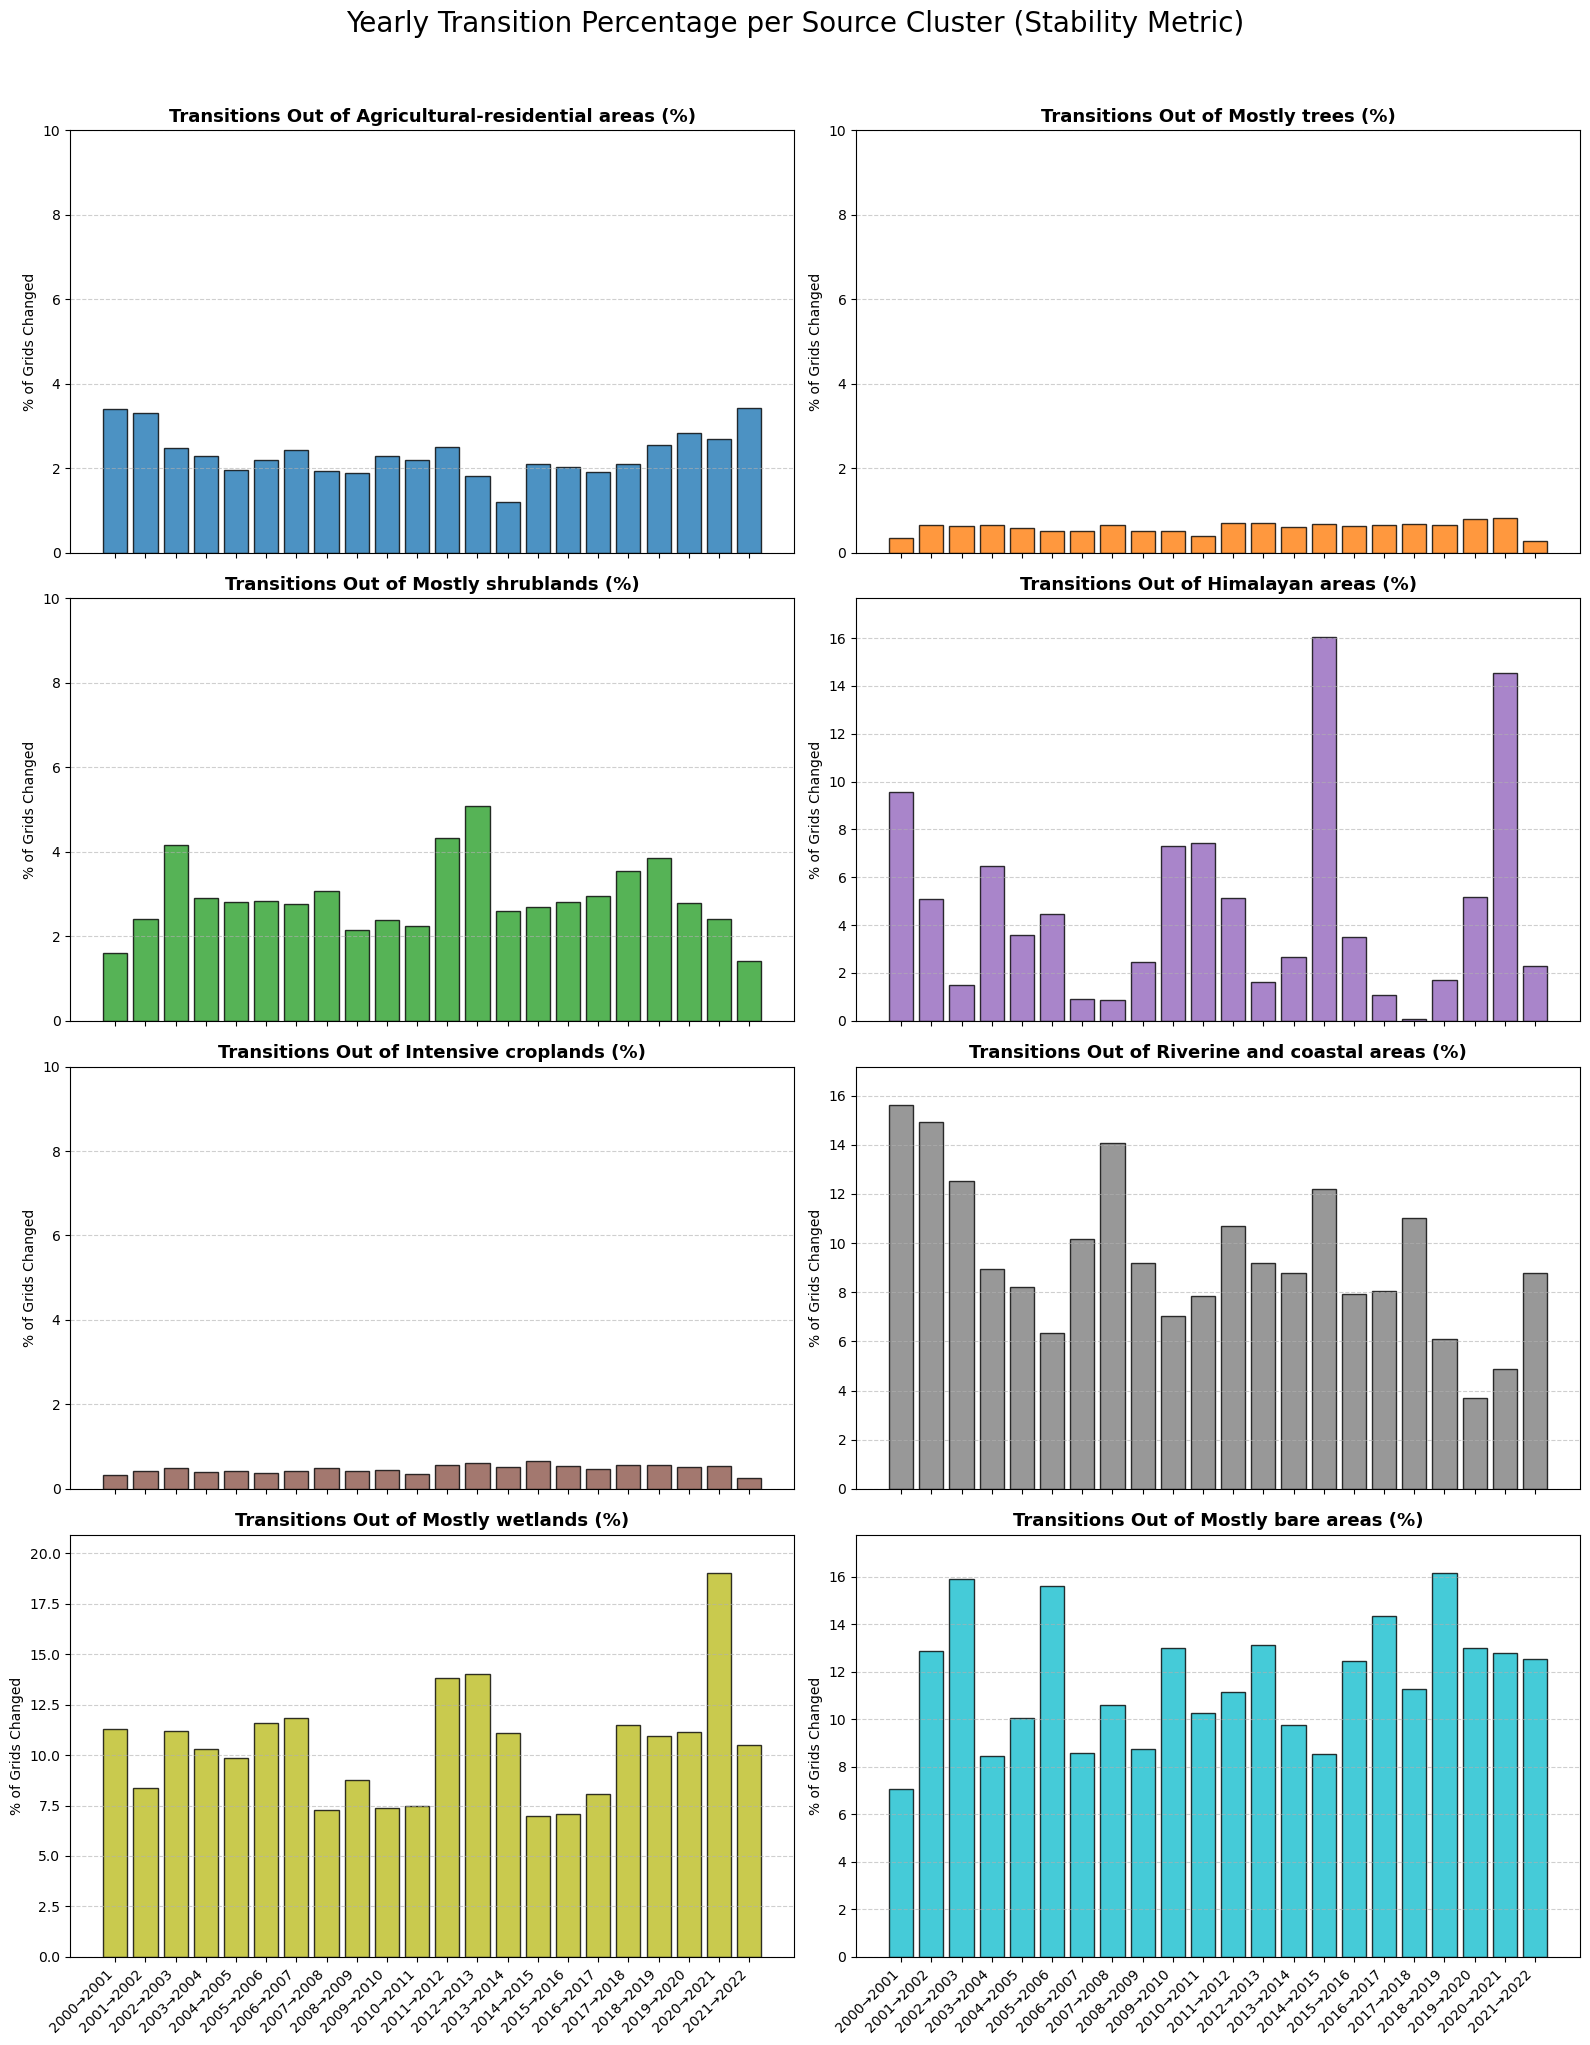

In [11]:
plot_transitions_per_cluster_percentage(wide_data, n_clusters=8)

## Finding problematic grids

In [ ]:
def identify_problematic_grids(wide_df, YEARS, transitions_threshold=8):
    """Identifies highly unstable 'flickering' grids and calculates cross-temporal entropy.

    Parameters:
    -----------
    wide_df : pd.DataFrame
        DataFrame where index is Grid ID and columns are years.
    YEARS : list
        List of year columns to evaluate (e.g., [2000, 2001, ..., 2022]).
    transitions_threshold : int
        Number of year-to-year changes above which a grid is flagged as highly
        unstable.

    Returns:
    --------
    metrics_df : pd.DataFrame
        A DataFrame indexed by Grid ID containing instability metrics.
    """
    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    df_clean = wide_df[year_cols].replace(-1, np.nan)

    # 1. Total absolute number of changes across the time series
    # Shifts columns along the year axis to compare t vs t+1
    changes = df_clean.ffill(axis=1).bfill(axis=1)
    num_transitions = (changes.diff(axis=1) != 0).sum(axis=1) - 1
    # Adjust for the first column's NaN diff
    num_transitions = num_transitions.clip(lower=0)

    # 2. Number of unique clusters a single grid visits
    unique_clusters_visited = df_clean.nunique(axis=1)

    # 3. Calculate Shannon Entropy over the time series for each grid
    # Grids that stay in 1 cluster will have entropy = 0.
    # Grids alternating evenly will have high entropy.
    def calculate_temporal_entropy(row):
        counts = row.dropna().value_counts()
        if len(counts) <= 1:
            return 0.0
        probs = counts / counts.sum()
        return -np.sum(probs * np.log2(probs))

    temporal_entropy = df_clean.apply(calculate_temporal_entropy, axis=1)

    # Consolidate results
    metrics_df = pd.DataFrame(
        {
            "total_transitions": num_transitions,
            "unique_clusters": unique_clusters_visited,
            "temporal_entropy": temporal_entropy,
        },
        index=wide_df.index,
    )

    # Flag grids breaking your stability criteria
    metrics_df["is_flickering_loop"] = (
        metrics_df["total_transitions"] >= transitions_threshold
    )

    return metrics_df

In [12]:
def identify_problematic_grids(
    wide_df, YEARS, transitions_threshold=8, output_csv="problematic_grids.csv"
):
    """Identifies highly unstable 'flickering' grids, calculates cross-temporal entropy,

    and saves the complete structured output into a sorted CSV file.

    Parameters:
    -----------
    wide_df : pd.DataFrame
        DataFrame where index is Grid ID and columns are years.
    YEARS : list
        List of year columns to evaluate (e.g., [2000, 2001, ..., 2022]).
    transitions_threshold : int
        Number of year-to-year changes above which a grid is flagged as highly
        unstable.
    output_csv : str
        The output file name for your exported CSV metrics.

    Returns:
    --------
    metrics_df : pd.DataFrame
        A DataFrame indexed by Grid ID containing instability metrics.
    """
    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    df_clean = wide_df[year_cols].replace(-1, np.nan)

    # 1. Total absolute number of changes across the time series
    # Shifts columns along the year axis to compare t vs t+1
    changes = df_clean.ffill(axis=1).bfill(axis=1)
    num_transitions = (changes.diff(axis=1) != 0).sum(axis=1) - 1
    # Adjust for the first column's NaN diff
    num_transitions = num_transitions.clip(lower=0)

    # 2. Number of unique clusters a single grid visits
    unique_clusters_visited = df_clean.nunique(axis=1)

    # 3. Calculate Shannon Entropy over the time series for each grid
    # Grids that stay in 1 cluster will have entropy = 0.
    # Grids alternating evenly will have high entropy.
    def calculate_temporal_entropy(row):
        counts = row.dropna().value_counts()
        if len(counts) <= 1:
            return 0.0
        probs = counts / counts.sum()
        return -np.sum(probs * np.log2(probs))

    temporal_entropy = df_clean.apply(calculate_temporal_entropy, axis=1)

    # Consolidate results
    metrics_df = pd.DataFrame(
        {
            "total_transitions": num_transitions,
            "unique_clusters": unique_clusters_visited,
            "temporal_entropy": temporal_entropy,
        },
        index=wide_df.index,
    )

    # Flag grids breaking your stability criteria
    metrics_df["is_flickering_loop"] = (
        metrics_df["total_transitions"] >= transitions_threshold
    )

    # --- NEW: Sorting and Exporting Logic ---
    # Sort in descending order to put the high-frequency flipping nodes at the top
    metrics_df = metrics_df.sort_values(
        by=["total_transitions", "temporal_entropy"], ascending=False
    )

    # Save to CSV
    metrics_df.to_csv(output_csv)
    print(f"Success: Instability metrics written to '{output_csv}'")

    return metrics_df

In [14]:
def identify_problematic_grids_fast(
    wide_df, YEARS, transitions_threshold=8, output_csv="problematic_grids.csv"
):
    """Highly optimized vectorized version for processing millions of grids rapidly."""
    print("Step 1: Filtering and aligning years...")
    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]

    # Convert to integer matrix (and handle NaNs with an invalid index token like -1)
    # Using a numpy matrix drops the massive overhead of pandas row-loops.
    matrix = wide_df[year_cols].to_numpy(dtype=np.int16)

    print("Step 2: Calculating transitions...")
    # Calculate transitions row-by-row using vectorized numpy diffs
    # Mask out any missing values if you use -1 for padding
    valid_mask = matrix != -1

    # Shift-compare across years to find switches
    # axis=1 compares columns
    transitions_matrix = (matrix[:, :-1] != matrix[:, 1:]) & valid_mask[:, :-1]
    num_transitions = transitions_matrix.sum(axis=1)

    print("Step 3: Calculating unique clusters and entropy via matrix pooling...")
    num_rows = matrix.shape[0]
    num_clusters = 8  # Based on your 0 to 7 cluster configuration

    # Count occurrences of each cluster per row using a vectorized approach
    # We build an explicit frequency distribution grid of (2000000, 8)
    counts = np.zeros((num_rows, num_clusters), dtype=np.int16)
    for c in range(num_clusters):
        counts[:, c] = np.sum(matrix == c, axis=1)

    # Number of unique clusters is where count > 0 along the cluster axis
    unique_clusters_visited = np.sum(counts > 0, axis=1)

    # Calculate row totals for probabilities (ignoring missing values/invalid labels)
    row_totals = counts.sum(axis=1, keepdims=True)
    # Avoid zero-division errors for completely empty rows if any exist
    row_totals[row_totals == 0] = 1

    # Probability matrix
    probs = counts / row_totals

    # Vectorized Shannon Entropy: -sum(p * log2(p))
    # We must handle log2(0) by masking zeroes out safely
    log_probs = np.zeros_like(probs)
    good_cells = probs > 0
    log_probs[good_cells] = np.log2(probs[good_cells])

    temporal_entropy = -np.sum(probs * log_probs, axis=1)

    print("Step 4: Packaging and saving to CSV...")
    # Consolidate back to a DataFrame at the very end
    metrics_df = pd.DataFrame(
        {
            "total_transitions": num_transitions,
            "unique_clusters": unique_clusters_visited,
            "temporal_entropy": temporal_entropy,
            "is_flickering_loop": num_transitions >= transitions_threshold,
        },
        index=wide_df.index,
    )

    # Sort down the worst offenders
    metrics_df = metrics_df.sort_values(
        by=["total_transitions", "temporal_entropy"], ascending=False
    )

    metrics_df.to_csv(output_csv)
    print(f"Done! Cleaned tracking saved to {output_csv}")

    return metrics_df

In [15]:
identify_problematic_grids_fast(wide_data, YEARS, transitions_threshold=8, output_csv="problematic_grids_fast.csv")

Step 1: Filtering and aligning years...
Step 2: Calculating transitions...
Step 3: Calculating unique clusters and entropy via matrix pooling...
Step 4: Packaging and saving to CSV...
Done! Cleaned tracking saved to problematic_grids_fast.csv


,total_transitions,unique_clusters,temporal_entropy,is_flickering_loop
s2_id,,,,
id_4147293280842809344,16,4,1.689946,True
id_4313735598708883456,15,5,2.087079,True
id_4148586272157335552,15,5,1.891852,True
id_4131590571170988032,15,4,1.850347,True
id_4134510633536192512,15,4,1.804896,True
...,...,...,...,...
id_4187179336450703360,0,1,-0.000000,False
id_4308489794373025792,0,1,-0.000000,False
id_4308495257571426304,0,1,-0.000000,False


Timeline heatmap generated successfully!


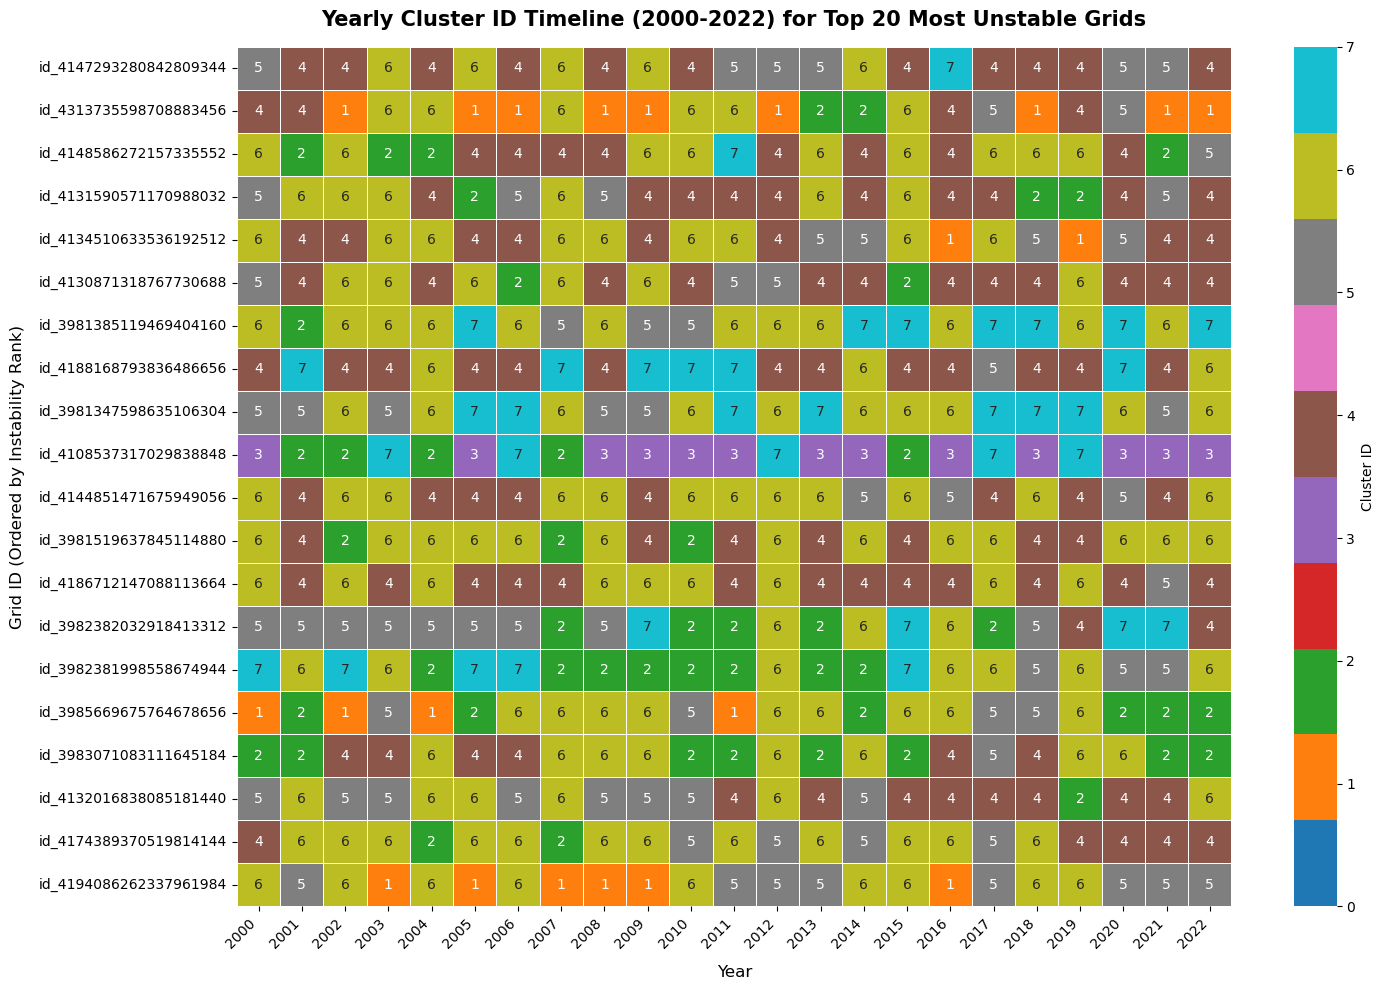

In [23]:
# 1. Load your sorted instability metrics CSV
metrics_df = pd.read_csv("problematic_grids_fast.csv", index_col="s2_id")

# 2. Extract the top 20 most problematic grid IDs
top_20_grid_ids = metrics_df.index[:20]

# 3. Filter your original time-series dataframe (wide_df) for these 20 grids
# Ensure your column headers are string representations of the years
years = [str(y) for y in range(2000, 2023)]
top_20_timeline = wide_data.loc[top_20_grid_ids, years]

# 4. Initialize subplots (using plt.subplots to avoid truncation and configuration errors)
fig, ax = plt.subplots(figsize=(15, 10))

# 5. Create a categorical heatmap
# 'tab10' palette works beautifully for representing discrete cluster IDs (0 to 7)
sns.heatmap(
    top_20_timeline,
    cmap="tab10",
    vmin=0,
    vmax=7,
    annot=True,  # Displays the explicit Cluster ID inside each block
    fmt="d",  # Formats annotations as integers
    linewidths=0.5,  # Adds thin grid lines between blocks for clarity
    cbar_kws={"label": "Cluster ID", "ticks": range(8)},
    ax=ax,
)

# 6. Customize titles and labels to ensure absolute readability
ax.set_title(
    "Yearly Cluster ID Timeline (2000-2022) for Top 20 Most Unstable Grids",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Year", fontsize=12, labelpad=10)
ax.set_ylabel("Grid ID (Ordered by Instability Rank)", fontsize=12, labelpad=10)

# Rotate labels slightly so they don't overlap at high resolutions
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# 7. Save the layout directly to a high-res image asset
plt.savefig("top_20_problematic_grids_timeline.png", dpi=300)
print("Timeline heatmap generated successfully!")